# Parsing .docx

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.0 MB/s eta 0:00:00a 0:00:01


In [3]:
from docx import Document
import re, os
from pathlib import Path

DOCX_DIR = "/kaggle/input/datasets/arnavtripathi01/renaissance-data/labels"
OUT_DIR = "/kaggle/working/processed_labels"

os.makedirs(OUT_DIR, exist_ok=True)

def parse_docx(path):
    doc = Document(path)
    text = "\n".join([p.text for p in doc.paragraphs])

    splits = re.split(r"(PDF p\d+)", text)

    data = {}
    current = None

    for chunk in splits:
        chunk = chunk.strip()
        if re.match(r"PDF p\d+", chunk):
            current = chunk
            data[current] = ""
        elif current:
            data[current] += chunk + "\n"

    return data

for file in os.listdir(DOCX_DIR):
    if file.endswith(".docx"):
        pages = parse_docx(os.path.join(DOCX_DIR, file))
        base = Path(file).stem

        for p, txt in pages.items():
            num = re.findall(r"\d+", p)[0]
            out = f"{OUT_DIR}/{base}_page_{num}.txt"

            with open(out, "w", encoding="utf-8") as f:
                f.write(txt.strip())

print("labels created:", len(os.listdir(OUT_DIR)))

labels created: 22


In [4]:
print(os.listdir("/kaggle/working/processed_labels")[:10])

['Guardiola - Tratado nobleza transcription_page_12.txt', 'Guardiola - Tratado nobleza transcription_page_14.txt', 'PORCONES.23.5 - 1628 transcription_page_3.txt', 'Guardiola - Tratado nobleza transcription_page_13.txt', 'PORCONES.748.6  1650 Transcription_page_4.txt', 'Covarrubias - Tesoro lengua transcription_page_7.txt', 'PORCONES.748.6  1650 Transcription_page_1.txt', 'PORCONES.228.38 - 1646 transcription_page_3.txt', 'PORCONES.228.38 - 1646 transcription_page_1.txt', 'PORCONES.228.38 - 1646 transcription_page_2.txt']


# Convert PDFs to Images

In [5]:
!apt-get update
!apt-get install -y poppler-utils

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://cli.github.com/packages stable InRelease [3,917 B]               
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease   
Get:9 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease   
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,945 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,620 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main 

In [6]:
from pdf2image import convert_from_path
from collections import defaultdict

PDF_DIR = "/kaggle/input/datasets/arnavtripathi01/renaissance-data/raw_pdfs"
LBL_DIR = "/kaggle/working/processed_labels"
IMG_DIR = "/kaggle/working/images"

os.makedirs(IMG_DIR, exist_ok=True)

def normalize(x):
    x = x.lower()
    x = x.replace(" transcription", "")
    
    # remove special characters except letters/numbers
    x = re.sub(r"[^a-z0-9]", "", x)
    
    return x

# build page map
page_map = defaultdict(list)

for f in os.listdir(LBL_DIR):
    m = re.match(r"(.*)_page_(\d+)\.txt", f)
    if m:
        base, p = m.groups()
        page_map[normalize(base)].append(int(p))

# convert only needed pages
for pdf in os.listdir(PDF_DIR):
    if not pdf.endswith(".pdf"): continue

    key = normalize(pdf[:-4])

    if key not in page_map:
        print("skip:", pdf)
        continue

    mn, mx = min(page_map[key]), max(page_map[key])
    print("processing:", pdf, mn, mx)

    pages = convert_from_path(
        os.path.join(PDF_DIR, pdf),
        dpi=200,
        first_page=mn,
        last_page=mx,
        thread_count=4
    )

    for i, pg in enumerate(pages, start=mn):
        pg.save(f"{IMG_DIR}/{key}_page_{i}.jpg", "JPEG")

print("images:", len(os.listdir(IMG_DIR)))

processing: PORCONES.748.6  1650.pdf 1 4


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94080000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


processing: PORCONES.228.38  1646.pdf 1 5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94080000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


processing: PORCONES.23.5 - 1628.pdf 1 4


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94080000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


processing: Buendia - Instruccion.pdf 2 4
processing: Guardiola - Tratado nobleza.pdf 12 14
processing: Covarrubias - Tesoro lengua.pdf 7 9
images: 22


(np.float64(-0.5), np.float64(8399.5), np.float64(11199.5), np.float64(-0.5))

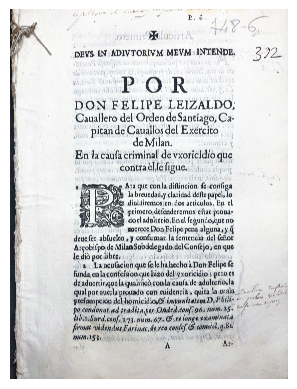

In [7]:
import cv2

img_path = os.path.join(IMG_DIR, os.listdir(IMG_DIR)[0])

img = cv2.imread(img_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

# Creating dataset

In [8]:
IMG_DIR = "/kaggle/working/images"
LBL_DIR = "/kaggle/working/processed_labels"

# SAME normalization as image step
def normalize(x):
    x = x.lower()
    x = x.replace(" transcription", "")
    x = re.sub(r"[^a-z0-9]", "", x)
    return x

# build label map
label_map = {}

for f in os.listdir(LBL_DIR):
    m = re.match(r"(.*)_page_(\d+)\.txt", f)
    if m:
        base, p = m.groups()
        key = f"{normalize(base)}_page_{p}"
        label_map[key] = os.path.join(LBL_DIR, f)

print("Label keys:", list(label_map.keys())[:5])

# match images
data = []

for img in os.listdir(IMG_DIR):
    if not img.endswith(".jpg"):
        continue

    key = img.replace(".jpg", "")  # already normalized
    if key in label_map:
        txt = open(label_map[key], encoding="utf-8").read().strip()

        data.append({
            "image": os.path.join(IMG_DIR, img),
            "text": txt
        })

print("Matched samples:", len(data))

df = pd.DataFrame(data)
df.to_csv("/kaggle/working/dataset.csv", index=False)

print("Dataset created:", len(df))

Label keys: ['guardiolatratadonobleza_page_12', 'guardiolatratadonobleza_page_14', 'porcones2351628_page_3', 'guardiolatratadonobleza_page_13', 'porcones74861650_page_4']
Matched samples: 22
Dataset created: 22


In [9]:
df.head(3)

,image,text
0,/kaggle/working/images/porcones74861650_page_1...,DEUS IN ADIUTORIUM MEUM INTENDE\nPOR\n \nDon F...
1,/kaggle/working/images/porcones2351628_page_4.jpg,"- left\nBosi. tit. de pace, vers. Quando vxor ..."
2,/kaggle/working/images/porcones228381646_page_...,"ticia de esta parte en ajuitar con certeza, y ..."


# Text Crop

# Basic Text Crop

In [10]:
CROP_DIR = "/kaggle/working/cropped_images"

os.makedirs(CROP_DIR, exist_ok=True)

def crop_text_region(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Invert + threshold
    _, thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

    # Find coordinates where text exists
    coords = np.column_stack(np.where(thresh > 0))

    if coords.shape[0] == 0:
        return img  # fallback

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    cropped = img[y_min:y_max, x_min:x_max]
    return cropped


for img_file in os.listdir(IMG_DIR):
    if img_file.endswith(".jpg"):
        path = os.path.join(IMG_DIR, img_file)
        img = cv2.imread(path)

        cropped = crop_text_region(img)

        cv2.imwrite(os.path.join(CROP_DIR, img_file), cropped)

print("Cropping done")

Cropping done


### Check

(np.float64(-0.5), np.float64(8398.5), np.float64(11198.5), np.float64(-0.5))

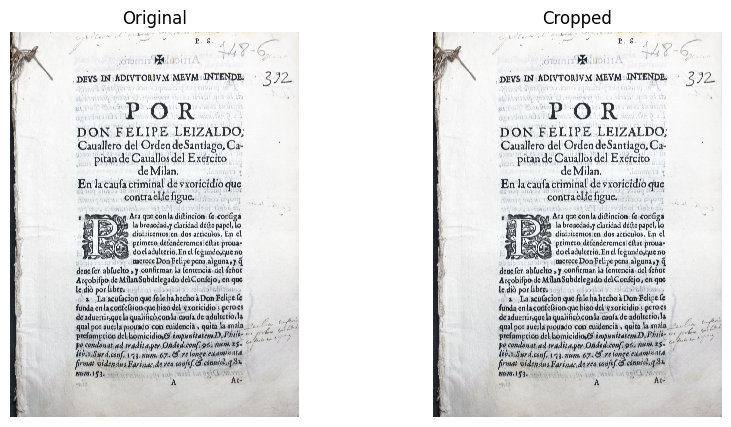

In [11]:
sample = os.listdir(CROP_DIR)[0]

orig = cv2.imread(os.path.join(IMG_DIR, sample))
crop = cv2.imread(os.path.join(CROP_DIR, sample))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Cropped")
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.axis("off")

# Projection Based Cropping

In [12]:
os.makedirs(CROP_DIR, exist_ok=True)

def crop(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    th = cv2.adaptiveThreshold(est daataloderestdaa
        blur,255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY_INV,
        25,15
    )

    h = np.sum(th, axis=1)
    v = np.sum(th, axis=0)

    ys = np.where(h > h.max()*0.1)[0]
    xs = np.where(v > v.max()*0.1)[0]

    if len(xs)==0 or len(ys)==0:
        return img

    return img[ys[0]:ys[-1], xs[0]:xs[-1]]

for f in os.listdir(IMG_DIR):
    if f.endswith(".jpg"):
        im = cv2.imread(os.path.join(IMG_DIR,f))
        cr = crop(im)
        cv2.imwrite(os.path.join(CROP_DIR,f), cr)

print("cropped:", len(os.listdir(CROP_DIR)))

cropped: 22


### Check

(np.float64(-0.5), np.float64(8057.5), np.float64(10047.5), np.float64(-0.5))

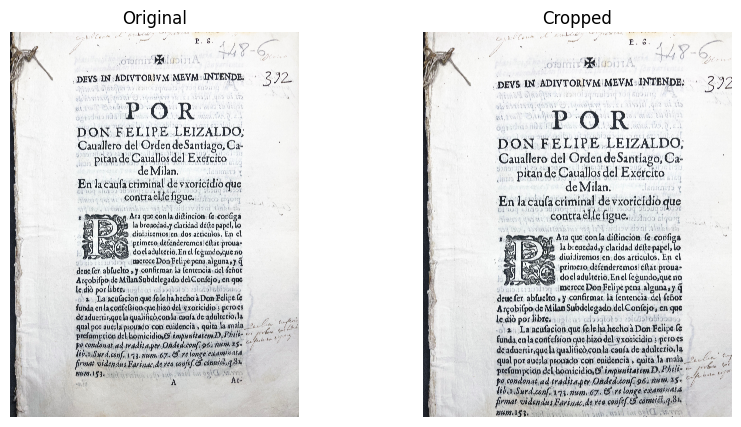

In [13]:
sample = os.listdir(CROP_DIR)[0]

orig = cv2.imread(os.path.join(IMG_DIR, sample))
crop = cv2.imread(os.path.join(CROP_DIR, sample))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Cropped")
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.axis("off")